Problem statement - Objective: Analyze sales data to identify top-performing products, regions, and customers, and uncover business insights.

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt # visualizing data
%matplotlib inline
import seaborn as sns

In [78]:
# import csv file
df_raw = pd.read_csv('sales_data_sample.csv', encoding= 'unicode_escape')
df = df_raw
df.head()


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [79]:
df.shape

(2823, 25)

In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ORDERNUMBER      2823 non-null   int64         
 1   QUANTITYORDERED  2823 non-null   int64         
 2   PRICEEACH        2823 non-null   float64       
 3   ORDERLINENUMBER  2823 non-null   int64         
 4   SALES            2823 non-null   float64       
 5   ORDERDATE        2823 non-null   datetime64[us]
 6   STATUS           2823 non-null   category      
 7   QTR_ID           2823 non-null   int64         
 8   MONTH_ID         2823 non-null   int64         
 9   YEAR_ID          2823 non-null   int64         
 10  PRODUCTLINE      2823 non-null   category      
 11  MSRP             2823 non-null   int64         
 12  PRODUCTCODE      2823 non-null   str           
 13  CUSTOMERNAME     2823 non-null   str           
 14  PHONE            2823 non-null   str           
 15

In [60]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [94]:
#check for null values
pd.isnull(df).sum()

ORDERNUMBER        0
QUANTITYORDERED    0
PRICEEACH          0
ORDERLINENUMBER    0
SALES              0
ORDERDATE          0
STATUS             0
QTR_ID             0
MONTH_ID           0
YEAR_ID            0
PRODUCTLINE        0
MSRP               0
PRODUCTCODE        0
CUSTOMERNAME       0
PHONE              0
ADDRESSLINE1       0
ADDRESSLINE2       0
CITY               0
STATE              0
POSTALCODE         0
COUNTRY            0
TERRITORY          0
LAST_NAME          0
FIRST_NAME         0
DEALSIZE           0
Month              0
Year               0
dtype: int64

In [93]:
# drop null values
df["ADDRESSLINE2"] = df["ADDRESSLINE2"].fillna(0)
df["STATE"] = df["STATE"].fillna(0)
df["TERRITORY"] = df["TERRITORY"].fillna(0)
df["POSTALCODE"] = df["POSTALCODE"].fillna(0)

In [85]:
# Convert date
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])

# Convert categories
cat_cols = ["STATUS", "PRODUCTLINE", "COUNTRY", "TERRITORY", "DEALSIZE"]

for col in cat_cols:
    df[col] = df[col].astype("category")

In [86]:
df.rename(columns= {'CONTACTFIRSTNAME':'FIRST_NAME'},inplace = True)

In [87]:
#Rename column
df.rename(columns= {'CONTACTLASTNAME':'LAST_NAME'},inplace = True)

In [88]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [89]:
type(df)

pandas.DataFrame

In [90]:
df["Month"] = df["ORDERDATE"].dt.month
df["Year"] = df["ORDERDATE"].dt.year

In [104]:
df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'LAST_NAME', 'FIRST_NAME', 'DEALSIZE', 'Month',
       'Year', 'Profit'],
      dtype='str')

In [103]:
df["Profit"] = df["SALES"] * 0.1 #Create New Profit column

In [71]:
#TOTAL SALES
df["SALES"].sum()

np.float64(506562.52)

In [72]:
df["ORDERNUMBER"].nunique() #Total orders

13

In [73]:
df.head(147)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,STATE,POSTALCODE,COUNTRY,TERRITORY,LAST_NAME,FIRST_NAME,DEALSIZE,Month,Year,Profit
10,10223,37,100.00,1,3965.66,2004-02-20,Shipped,1,2,2004,...,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium,2,2004,396.566
21,10361,20,72.55,13,1451.00,2004-12-17,Shipped,4,12,2004,...,NSW,2067,Australia,APAC,Huxley,Adrian,Small,12,2004,145.100
40,10270,21,100.00,9,4905.39,2004-07-19,Shipped,3,7,2004,...,NSW,2067,Australia,APAC,Huxley,Adrian,Medium,7,2004,490.539
47,10347,30,100.00,1,3944.70,2004-11-29,Shipped,4,11,2004,...,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium,11,2004,394.470
51,10391,24,100.00,4,2416.56,2005-03-09,Shipped,1,3,2005,...,NSW,2060,Australia,APAC,O'Hara,Anna,Small,3,2005,241.656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2667,10120,43,76.00,14,3268.00,2003-04-29,Shipped,2,4,2003,...,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium,4,2003,326.800
2673,10223,26,67.20,15,1747.20,2004-02-20,Shipped,1,2,2004,...,Victoria,3004,Australia,APAC,Ferguson,Peter,Small,2,2004,174.720
2685,10361,44,100.00,10,5001.92,2004-12-17,Shipped,4,12,2004,...,NSW,2067,Australia,APAC,Huxley,Adrian,Medium,12,2004,500.192
2764,10361,35,100.00,11,4277.35,2004-12-17,Shipped,4,12,2004,...,NSW,2067,Australia,APAC,Huxley,Adrian,Medium,12,2004,427.735


In [96]:
df.groupby("PRODUCTLINE")["SALES"].sum().sort_values(ascending=False)  #Sales by Product Line

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64

In [97]:
df.groupby("COUNTRY")["SALES"].sum().sort_values(ascending=False) #4.4 Sales by Country

COUNTRY
USA            3627982.83
Spain          1215686.92
France         1110916.52
Australia       630623.10
UK              478880.46
Italy           374674.31
Finland         329581.91
Norway          307463.70
Singapore       288488.41
Denmark         245637.15
Canada          224078.56
Germany         220472.09
Sweden          210014.21
Austria         202062.53
Japan           188167.81
Switzerland     117713.56
Belgium         108412.62
Philippines      94015.73
Ireland          57756.43
Name: SALES, dtype: float64

In [98]:
df.shape
df["COUNTRY"].nunique()

19

In [99]:
df.groupby("CUSTOMERNAME")["SALES"].sum().nlargest(5) #4.5 Top 5 Customers

CUSTOMERNAME
Euro Shopping Channel           912294.11
Mini Gifts Distributors Ltd.    654858.06
Australian Collectors, Co.      200995.41
Muscle Machine Inc              197736.94
La Rochelle Gifts               180124.90
Name: SALES, dtype: float64

In [100]:
#4.6 Monthly Sales Trend
df.groupby("Month")["SALES"].sum()

Month
1      785874.44
2      810441.90
3      754501.39
4      669390.96
5      923972.56
6      454756.78
7      514875.97
8      659310.57
9      584724.27
10    1121215.22
11    2118885.67
12     634679.12
Name: SALES, dtype: float64

In [101]:
#4.7 Best Selling Product (by quantity)
df.groupby("PRODUCTLINE")["QUANTITYORDERED"].sum().idxmax()

'Classic Cars'

In [105]:
#Most Profitable Country
df.groupby("COUNTRY")["Profit"].sum().idxmax()

'USA'

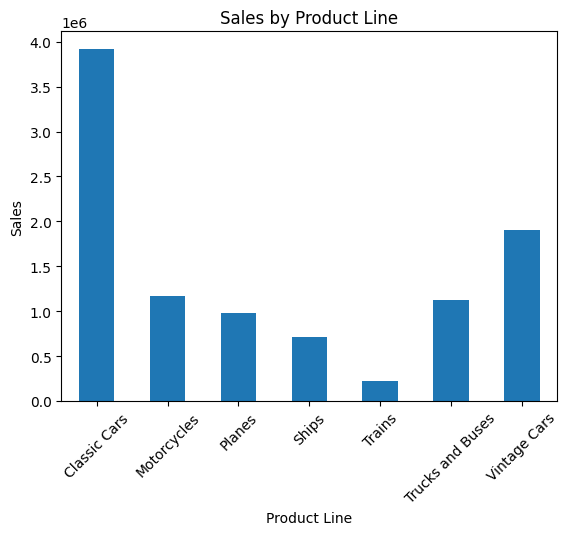

In [106]:
#Bar Chart → Sales by Product Line

df.groupby("PRODUCTLINE")["SALES"].sum().plot(kind="bar")
plt.title("Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

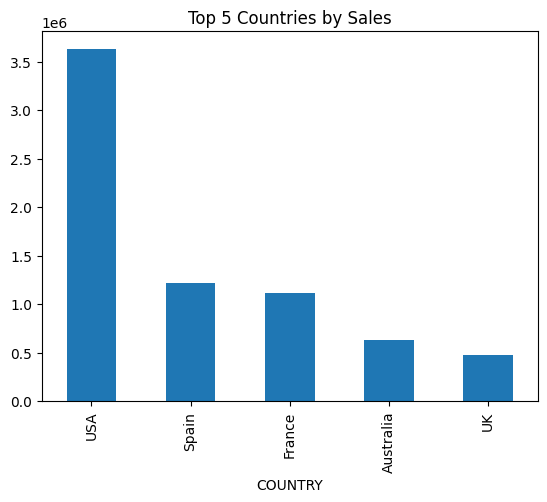

In [107]:
#Bar Chart → Sales by Country (Top 5)
df.groupby("COUNTRY")["SALES"].sum().nlargest(5).plot(kind="bar")
plt.title("Top 5 Countries by Sales")
plt.show()

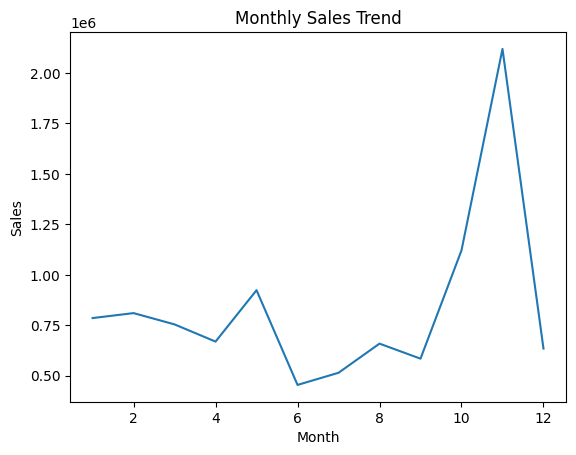

In [108]:
#Line Chart → Monthly Sales Trend
df.groupby("Month")["SALES"].sum().plot(kind="line")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

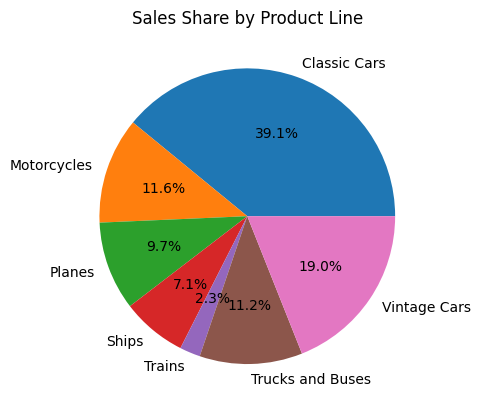

In [109]:
#Pie Chart → Sales Share by Product Line

df.groupby("PRODUCTLINE")["SALES"].sum().plot(kind="pie", autopct='%1.1f%%')
plt.title("Sales Share by Product Line")
plt.ylabel("")
plt.show()


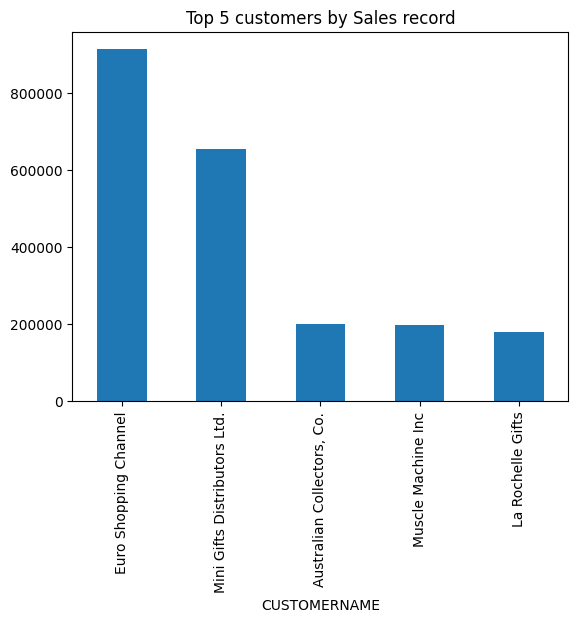

In [110]:
df.groupby("CUSTOMERNAME")["SALES"].sum().nlargest(5).plot(kind="bar")
plt.title("Top 5 customers by Sales record")
plt.show() #Top five customers with sale record
    

In [117]:
total_sales = df["SALES"].sum()

country_sales = df.groupby("COUNTRY")["SALES"].sum()

percentage_country = (country_sales / total_sales) * 100
percentage_country.sort_values(ascending=False)

COUNTRY
USA            36.161836
Spain          12.117332
France         11.073035
Australia       6.285721
UK              4.773230
Italy           3.734558
Finland         3.285100
Norway          3.064637
Singapore       2.875502
Denmark         2.448383
Canada          2.233498
Germany         2.197551
Sweden          2.093312
Austria         2.014054
Japan           1.875558
Switzerland     1.173307
Belgium         1.080600
Philippines     0.937100
Ireland         0.575686
Name: SALES, dtype: float64

In [ ]:
total_sales = df["SALES"].sum()

country_sales = df.groupby("COUNTRY")["SALES"].sum()

percentage_country = (country_sales / total_sales) * 100
percentage_country.sort_values(ascending=False)

Some insights generated -

1.Classic Cars is the top-performing product line, generating the highest overall revenue among all categories with 39% of the total share.
2.USA contribute highest share of 36% of the total sales.
3.Sales show a strong seasonal trend, with the highest revenue recorded during the October to December period, indicating peak demand in the last quarter.
4.Euro Shopping Channel is the top customer, contributing the highest individual sales.

A combined analysis shows that Classic Cars sold in the USA, particularly by Euro Shopping Channel, contributed significantly to peak sales during the October–December period.
